In [1]:
# %%
import json
import os
import sys
import importlib
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import pairwise_distances, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
# %%
PROJECT_ROOT = Path("../..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.counterfactuals.core import (
    BasisGenerator,
    TSFeatureSchema,
    TargetSpec,
    GeneratorConfig,
    LossWeights,
)

from src.counterfactuals.metrics import (
    evaluate_cf_set,
)

from src.baselines.comte import CoMTEGenerator
from src.baselines.forecast import ForecastCFGenerator

from src.data_loader.aep.AEPTorchDataset import AEPTorchDataset
from src.models.aep.TransformerModel import TransformerModel

In [62]:
# %%
DEFAULT_DATA_DIR = str(PROJECT_ROOT / "data" / "processed" / "AEP" / "dataset")
DEFAULT_FILENAME = "energydata_complete.csv"
DEFAULT_OUTPUT_ROOT = str(PROJECT_ROOT / "outputs" / "AEP")
MODEL_NAME = "transformer"

BASIS_TYPES = ["bspline", "rbf", "wavelet", "polynomial", "fourier"]
NUM_BASIS_GRID = [4, 6, 8, 10]

NUM_QUERY_SAMPLES = 20
NUM_CFS = 3
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 7 else "cpu"
)

RUN_DIR = Path(DEFAULT_OUTPUT_ROOT) / MODEL_NAME
VIZ_DIR = RUN_DIR / "visualizations_cf"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

print("Using device:", device)
print("Run dir:", RUN_DIR)
print("Viz dir:", VIZ_DIR)

Using device: cuda
Run dir: /workspace/nirban/vaibhav/counterfactual_basis_kernel/outputs/AEP/transformer
Viz dir: /workspace/nirban/vaibhav/counterfactual_basis_kernel/outputs/AEP/transformer/visualizations_cf


In [4]:
# %%
def predict_energy_normalised(model, sequence_np, device):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(sequence_np, dtype=torch.float32).unsqueeze(0).to(device)
        pred = model(x).view(-1)[0].item()
    return float(pred)


def inv_trans(norm_val, p1, p2):
    """
    Inverse min-max transform back to original Wh scale.
    """
    return np.asarray(norm_val) * p2 + p1


def get_test_sample(loader, idx: int = 0):
    cumulative = 0
    for batch in loader:
        X, y = batch[0], batch[-1]
        bs = X.shape[0]
        if cumulative + bs > idx:
            local_i = idx - cumulative
            return X[local_i].cpu().numpy(), float(y[local_i].cpu().item())
        cumulative += bs
    raise IndexError(f"Index {idx} out of range (dataset size={cumulative})")


def collect_labels(loader):
    labels = []
    for batch in loader:
        y = batch[-1]
        labels.extend(y.detach().cpu().numpy().flatten().tolist())
    return np.array(labels)


def compute_mad_inv_from_loader(loader, n_features, mad_floor=1e-2, mad_clip=50.0):
    all_data = []
    for batch in loader:
        X = batch[0].detach().cpu().numpy()   # (B, T, D)
        all_data.append(X.reshape(-1, n_features))
    flat = np.concatenate(all_data, axis=0)
    median_vals = np.median(flat, axis=0)
    mad_vals = np.median(np.abs(flat - median_vals), axis=0)
    mad_vals = np.maximum(mad_vals, mad_floor)
    mad_inv = 1.0 / mad_vals
    mad_inv = np.clip(mad_inv, 0.0, mad_clip)
    return mad_inv.astype(np.float32)


def make_target_spec_aep(
    pred_norm: float,
    p1: float,
    p2: float,
    reduction_pct: Tuple[float, float] = (0.10, 0.25),
    band_half_width_wh: float = 10.0,
):
    """
    Counterfactual question:
      'What needs to change to reduce appliance energy by X%?'
    """
    current_wh = float(inv_trans(pred_norm, p1, p2))
    min_r, max_r = reduction_pct
    r = np.random.uniform(min_r, max_r)

    target_wh = max(0.0, current_wh * (1.0 - r))
    target_norm = float((target_wh - p1) / max(p2, 1e-8))

    band_half_norm = band_half_width_wh / max(p2, 1e-8)
    lo = max(0.0, target_norm - band_half_norm)
    hi = min(1.0, target_norm + band_half_norm)

    target = TargetSpec(
        task_type="regression",
        target_value=float(target_norm),
        target_range=(float(lo), float(hi)),
    )
    return target, float(target_wh), float(target_norm), float(lo), float(hi)


def append_series_records(
    records: List[dict],
    query_idx: int,
    series_np: np.ndarray,
    feature_cols: List[str],
    series_type: str,
    method: str,
    K,
    cf_id: int,
    pred_norm: float,
    pred_wh: float,
    target_norm: float,
    target_wh: float,
):
    T, D = series_np.shape
    for t in range(T):
        for d in range(D):
            records.append({
                "query_idx": int(query_idx),
                "series_type": series_type,
                "method": method,
                "K": K,
                "cf_id": int(cf_id),
                "t": int(t),
                "feature_idx": int(d),
                "feature_name": feature_cols[d],
                "value": float(series_np[t, d]),
                "pred_norm": float(pred_norm),
                "pred_wh": float(pred_wh),
                "target_norm": float(target_norm),
                "target_wh": float(target_wh),
            })


def append_x_vs_xcf_records(
    records,
    query_idx: int,
    x_np: np.ndarray,
    xcf_np: np.ndarray,
    feature_cols: list,
    method: str,
    K,
    cf_id: int,
    pred_wh_orig: float,
    pred_wh_cf: float,
    target_wh: float,
):
    T, D = x_np.shape
    delta_np = xcf_np - x_np

    for t in range(T):
        for d in range(D):
            records.append({
                "query_idx": int(query_idx),
                "method": method,
                "K": K,
                "cf_id": int(cf_id),
                "t": int(t),
                "feature_idx": int(d),
                "feature_name": feature_cols[d],
                "x": float(x_np[t, d]),
                "x_cf": float(xcf_np[t, d]),
                "delta": float(delta_np[t, d]),
                "abs_delta": float(abs(delta_np[t, d])),
                "pred_wh_orig": float(pred_wh_orig),
                "pred_wh_cf": float(pred_wh_cf),
                "target_wh": float(target_wh),
            })


def mean_pairwise_distance_from_cfs(cfs: torch.Tensor) -> float:
    x = cfs.detach().cpu().numpy().reshape(cfs.shape[0], -1)
    if x.shape[0] <= 1:
        return 0.0
    D = pairwise_distances(x, metric="euclidean")
    tri = D[np.triu_indices_from(D, k=1)]
    return float(np.mean(tri)) if tri.size > 0 else 0.0


def build_eval_row_aep(
    query_idx: int,
    method: str,
    K,
    pred_wh_orig: float,
    target_wh: float,
    target_norm: float,
    band_lo: float,
    band_hi: float,
    metrics: Dict[str, float],
    p1: float,
    p2: float,
):
    pred_norm_cf = float(metrics["pred_summary"])
    pred_wh_cf = float(inv_trans(pred_norm_cf, p1, p2))

    return {
        "query_idx": int(query_idx),
        "method": method,
        "K": K,
        "pred_wh_orig": float(pred_wh_orig),
        "pred_wh_cf": float(pred_wh_cf),
        "target_wh": float(target_wh),
        "target_norm": float(target_norm),
        "band_lo_norm": float(band_lo),
        "band_hi_norm": float(band_hi),
        "band_lo_wh": float(inv_trans(band_lo, p1, p2)),
        "band_hi_wh": float(inv_trans(band_hi, p1, p2)),
        "validity": float(metrics["validity"]),
        "proximity": float(metrics["proximity"]),
        "coeff_sparsity": float(metrics["coeff_sparsity"]),
        "group_sparsity": float(metrics["group_sparsity"]),
        "smoothness": float(metrics["smoothness"]),
        "diversity": float(metrics["diversity"]),
        "diversity_pairwise": float(metrics["diversity_pairwise"]),
        "total": float(metrics["total"]),
        "is_valid": bool(metrics["is_valid"]),
        "pred_summary": float(metrics["pred_summary"]),
        "point_gap_norm": float(metrics["point_gap"]),
        "band_hit": bool(metrics["is_valid"]),
    }

In [5]:
# %%
ds = AEPTorchDataset(data_dir=DEFAULT_DATA_DIR)
train_loader, val_loader, test_loader = ds.load(DEFAULT_FILENAME)

# This matches the older AEP counterfactual notebook
feature_cols = [
    "nsm", "lights",
    "T1", "T2", "T3", "T4", "RH_4",
    "T5", "T6", "T7", "RH_7",
    "T8", "RH_8", "RH_9",
    "T_out", "Press_mm_hg", "RH_out",
    "Windspeed", "Visibility", "Tdewpoint",
    "Appliances",
]

n_features = len(feature_cols)
seq_len = 12

print("Features:", feature_cols)
print("n_features:", n_features)
print("seq_len:", seq_len)
print("Train:", len(train_loader.dataset), "| Val:", len(val_loader.dataset), "| Test:", len(test_loader.dataset))

25 14209
25 1579
25 3947
Features: ['nsm', 'lights', 'T1', 'T2', 'T3', 'T4', 'RH_4', 'T5', 'T6', 'T7', 'RH_7', 'T8', 'RH_8', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'Appliances']
n_features: 21
seq_len: 12
Train: 14197 | Val: 1567 | Test: 3935


In [6]:
# %%
raw_full = pd.read_csv(os.path.join(DEFAULT_DATA_DIR, DEFAULT_FILENAME))
raw_full = raw_full.drop(columns=["rv1", "rv2"], errors="ignore")

raw_train, raw_test = train_test_split(raw_full, test_size=0.20, shuffle=False)
raw_train, raw_val = train_test_split(raw_train, test_size=0.10, shuffle=False)

target_vals_test = raw_test["Appliances"].values.astype(float)
p1 = float(target_vals_test.min())
p2 = float(target_vals_test.max() - target_vals_test.min())

print("Inverse-transform params:")
print("  min =", p1)
print("  range =", p2)

Inverse-transform params:
  min = 20.0
  range = 830.0


In [7]:
# %%
with open(RUN_DIR / "model_spec.json", "r") as f:
    model_spec = json.load(f)

model_kwargs = model_spec.get("model_kwargs", {})
trained_model = TransformerModel(input_size=n_features, **model_kwargs).to(device)

ckpt_path = RUN_DIR / "transformer_best_last.pth"
if not ckpt_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    trained_model.load_state_dict(checkpoint["model_state_dict"])
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    trained_model.load_state_dict(checkpoint["state_dict"])
else:
    trained_model.load_state_dict(checkpoint)

trained_model.eval()

print("Loaded:", ckpt_path.name)
print("Parameters:", sum(p.numel() for p in trained_model.parameters()))
print("Model kwargs:", model_kwargs)

Loaded: transformer_best_last.pth
Parameters: 276097
Model kwargs: {'d_model': 128, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 256, 'dropout': 0.2}


In [8]:
# %%
preds_list, actuals_list = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_hat = trained_model(X_batch).cpu().numpy().ravel()
        preds_list.extend(y_hat)
        actuals_list.extend(y_batch.numpy().ravel())

preds_norm = np.array(preds_list)
actual_norm = np.array(actuals_list)

preds_wh = inv_trans(preds_norm, p1, p2)
actual_wh = inv_trans(actual_norm, p1, p2)

rmse = np.sqrt(mean_squared_error(actual_wh, preds_wh))
mae = mean_absolute_error(actual_wh, preds_wh)
r2 = r2_score(actual_wh, preds_wh)

print("AEP Transformer validation")
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

AEP Transformer validation
RMSE: 60.0843888964721
MAE : 27.372350692749023
R2  : 0.526431679725647


In [9]:
# %%
context_features = ["nsm", "weekday_sin", "weekday_cos"]
action_features = ["lights", "Appliances"]

# Because the final 21-dim feature list does not include weekday_sin / weekday_cos
# in the same way as the older notebook comments, use what is actually present:
context_features = [f for f in context_features if f in feature_cols]
action_features = [f for f in action_features if f in feature_cols]

roles = []
for f in feature_cols:
    if f in context_features:
        roles.append("context")
    elif f in action_features:
        roles.append("action")
    else:
        roles.append("state")

context_idxs = [i for i, r in enumerate(roles) if r == "context"]
action_idxs = [i for i, r in enumerate(roles) if r == "action"]
state_idxs = [i for i, r in enumerate(roles) if r == "state"]

mad_inv = compute_mad_inv_from_loader(train_loader, n_features)

action_groups = {
    f"ch_{j}_{feature_cols[j]}": [j]
    for j, role in enumerate(roles)
    if role in ("action", "state")
}

aep_schema = TSFeatureSchema(
    feature_names=feature_cols,
    roles=roles,
    min_vals=np.zeros(n_features, dtype=np.float32),
    max_vals=np.ones(n_features, dtype=np.float32),
    mad_inv=mad_inv.astype(np.float32),
    action_groups=action_groups,
)

print("Context:", context_features)
print("Action :", [feature_cols[i] for i in action_idxs])
print("State  :", [feature_cols[i] for i in state_idxs[:5]], "...")

Context: ['nsm']
Action : ['lights', 'Appliances']
State  : ['T1', 'T2', 'T3', 'T4', 'RH_4'] ...


In [10]:
# %%
loss_weights = LossWeights(
    validity=1.0,
    proximity=0.35,
    sparsity=0.02,
    diversity=0.20,
    smoothness=0.25,
    channel_sparsity=0.15,
    state_lock=0.0,
)

gen_config = GeneratorConfig(
    editable_roles=("action", "state"),
    allow_state_edits=True,
    init_std=0.05,
    lr=0.02,
    max_iter=500,
    eta_min=1e-4,
    gradient_clip_norm=1.0,
    early_stop_tol_reg=0.01,
    early_stop_patience=120,
    clamp_during_optim=True,
    num_restarts=6,
    adam_steps=500,
    lbfgs_steps=0,
    rho_init=10.0,
    rho_growth=1.4,
    rho_max=1e4,
    prevalid_cleanup_scale=0.10,
    div_start_frac=0.10,
)

print("Loss/config ready")

Loss/config ready


In [11]:
# %%
basis_generators = {}
for b in BASIS_TYPES:
    basis_generators[b] = {}
    for K in NUM_BASIS_GRID:
        basis_generators[b][K] = BasisGenerator(
            model=trained_model,
            sequence_length=seq_len,
            feature_dim=n_features,
            basis_type=b,
            num_basis=K,
            device=str(device),
            config=gen_config,
        )

# baseline_generators = {
#     "comte": CoMTEGenerator(
#         model=trained_model,
#         sequence_length=seq_len,
#         feature_dim=n_features,
#         device=str(device),
#         config=gen_config,
#         mode="standard",
#     ),
# }
baseline_generators = {
    "comte": CoMTEGenerator(
        model=trained_model,
        sequence_length=seq_len,
        feature_dim=n_features,
        device=str(device),
        config=gen_config,
        mode="standard",
    ),
    "forecast": ForecastCFGenerator(
        model=trained_model,
        sequence_length=seq_len,
        feature_dim=n_features,
        device=str(device),
        config=gen_config,
    ),
}

print("Basis generators:", BASIS_TYPES)
print("Baselines:", list(baseline_generators.keys()))

Basis generators: ['bspline', 'rbf', 'wavelet', 'polynomial', 'fourier']
Baselines: ['comte', 'forecast']


In [12]:
# %%
def build_aep_test_window_metadata(default_data_dir=DEFAULT_DATA_DIR, filename=DEFAULT_FILENAME, n_past=12):
    raw = pd.read_csv(os.path.join(default_data_dir, filename))
    raw = raw.drop(columns=["rv1", "rv2"], errors="ignore")

    raw["date"] = pd.to_datetime(raw["date"])
    raw["date_only"] = raw["date"].dt.strftime("%Y-%m-%d")
    raw["time_only"] = raw["date"].dt.strftime("%H:%M:%S")

    train_raw, test_raw = train_test_split(raw, test_size=0.20, shuffle=False)
    train_raw, val_raw = train_test_split(train_raw, test_size=0.10, shuffle=False)

    test_raw = test_raw.reset_index(drop=True).copy()

    # windows correspond to target rows from index n_past .. end-1
    meta_rows = []
    for i in range(n_past, len(test_raw)):
        meta_rows.append({
            "query_idx": i - n_past,
            "target_timestamp": test_raw.loc[i, "date"],
            "date": test_raw.loc[i, "date_only"],
            "time": test_raw.loc[i, "time_only"],
            "window_start_timestamp": test_raw.loc[i - n_past, "date"],
            "window_end_timestamp": test_raw.loc[i - 1, "date"],
        })

    return pd.DataFrame(meta_rows), test_raw

aep_meta_df, raw_test_timeline_df = build_aep_test_window_metadata()
print(aep_meta_df.head())
print("Metadata rows:", len(aep_meta_df), "| test dataset size:", len(test_loader.dataset))

   query_idx    target_timestamp        date      time window_start_timestamp  \
0          0 2016-04-30 10:20:00  2016-04-30  10:20:00    2016-04-30 08:20:00   
1          1 2016-04-30 10:30:00  2016-04-30  10:30:00    2016-04-30 08:30:00   
2          2 2016-04-30 10:40:00  2016-04-30  10:40:00    2016-04-30 08:40:00   
3          3 2016-04-30 10:50:00  2016-04-30  10:50:00    2016-04-30 08:50:00   
4          4 2016-04-30 11:00:00  2016-04-30  11:00:00    2016-04-30 09:00:00   

  window_end_timestamp  
0  2016-04-30 10:10:00  
1  2016-04-30 10:20:00  
2  2016-04-30 10:30:00  
3  2016-04-30 10:40:00  
4  2016-04-30 10:50:00  
Metadata rows: 3935 | test dataset size: 3935


In [13]:
# %%
def run_single_query_aep(
    query_idx: int,
    train_loader,
    test_loader,
    model,
    aep_schema,
    basis_generators,
    baseline_generators,
    feature_cols,
    p1,
    p2,
    device,
    num_cfs: int = 3,
):
    query_np, true_y_norm = get_test_sample(test_loader, idx=int(query_idx))
    pred_norm = predict_energy_normalised(model, query_np, device)
    pred_wh = float(inv_trans(pred_norm, p1, p2))

    target, target_wh, target_norm, lo, hi = make_target_spec_aep(
        pred_norm=pred_norm,
        p1=p1,
        p2=p2,
        reduction_pct=(0.10, 0.25),
        band_half_width_wh=10.0,
    )

    print(f"\nQuery idx={query_idx} | pred={pred_wh:.2f} Wh | target≈{target_wh:.2f} Wh")

    query_tensor = torch.tensor(query_np, dtype=torch.float32, device=device)

    eval_records = []
    cf_bank_records = []
    x_vs_xcf_records = []

    append_series_records(
        records=cf_bank_records,
        query_idx=int(query_idx),
        series_np=query_np,
        feature_cols=feature_cols,
        series_type="original",
        method="original",
        K=None,
        cf_id=0,
        pred_norm=pred_norm,
        pred_wh=pred_wh,
        target_norm=target_norm,
        target_wh=target_wh,
    )

    # ---------- basis methods ----------
    for basis_type in BASIS_TYPES:
        best_run = None
        best_cfs_np = None

        for K in NUM_BASIS_GRID:
            cfs, info = basis_generators[basis_type][K].generate(
                query_instance=query_tensor,
                target=target,
                schema=aep_schema,
                num_cfs=num_cfs,
                loss_weights=loss_weights,
                verbose=False,
            )

            cfs_np = cfs.detach().cpu().numpy()

            metrics = evaluate_cf_set(
                model=model,
                x_orig=query_tensor,
                x_cf=cfs,
                target=target,
                schema=aep_schema,
                device=device,
                W=None,
                prox_mode="raw_mean",
            )

            pair_div = mean_pairwise_distance_from_cfs(cfs)

            this = {
                "K": K,
                "validity": metrics["validity"],
                "proximity": metrics["proximity"],
                "coeff_sparsity": metrics["coeff_sparsity"],
                "group_sparsity": metrics["group_sparsity"],
                "smoothness": metrics["smoothness"],
                "diversity": metrics["diversity"],                 # log-det style
                "diversity_pairwise": pair_div,                   # easier to interpret
                "total": metrics["total"],
                "is_valid": float(metrics["is_valid"]),
                "pred_summary": metrics["pred_summary"],
                "point_gap": metrics["point_gap"],
            }

            if best_run is None:
                best_run = this
                best_cfs_np = cfs_np
            else:
                old_key = (
                    0.0 if best_run["is_valid"] else 1.0,
                    best_run["validity"],
                    best_run["proximity"],
                    best_run["group_sparsity"],
                    best_run["smoothness"],
                    -best_run["diversity_pairwise"],
                )
                new_key = (
                    0.0 if this["is_valid"] else 1.0,
                    this["validity"],
                    this["proximity"],
                    this["group_sparsity"],
                    this["smoothness"],
                    -this["diversity_pairwise"],
                )
                if new_key < old_key:
                    best_run = this
                    best_cfs_np = cfs_np

        print(
            f"  {basis_type:10s} K={best_run['K']:2d} | "
            f"validity={best_run['validity']:.6f} | "
            f"point_gap={best_run['point_gap']:.6f} | "
            f"proximity={best_run['proximity']:.6f} | "
            f"group={best_run['group_sparsity']:.6f} | "
            f"smoothness={best_run['smoothness']:.3e} | "
            f"logdet_div={best_run['diversity']:.6f} | "
            f"pair_div={best_run['diversity_pairwise']:.6f} | "
            f"valid={bool(best_run['is_valid'])}"
        )

        eval_records.append(
            build_eval_row_aep(
                query_idx=query_idx,
                method=basis_type,
                K=best_run["K"],
                pred_wh_orig=pred_wh,
                target_wh=target_wh,
                target_norm=target_norm,
                band_lo=lo,
                band_hi=hi,
                metrics=best_run,
                p1=p1,
                p2=p2,
            )
        )

        best_cf_pred_norm = float(best_run["pred_summary"])
        best_cf_pred_wh = float(inv_trans(best_cf_pred_norm, p1, p2))

        for cf_id in range(best_cfs_np.shape[0]):
            cf_i_np = best_cfs_np[cf_id]

            append_series_records(
                records=cf_bank_records,
                query_idx=int(query_idx),
                series_np=cf_i_np,
                feature_cols=feature_cols,
                series_type="cf",
                method=basis_type,
                K=best_run["K"],
                cf_id=cf_id,
                pred_norm=best_cf_pred_norm,
                pred_wh=best_cf_pred_wh,
                target_norm=target_norm,
                target_wh=target_wh,
            )

            append_x_vs_xcf_records(
                records=x_vs_xcf_records,
                query_idx=int(query_idx),
                x_np=query_np,
                xcf_np=cf_i_np,
                feature_cols=feature_cols,
                method=basis_type,
                K=best_run["K"],
                cf_id=cf_id,
                pred_wh_orig=pred_wh,
                pred_wh_cf=best_cf_pred_wh,
                target_wh=target_wh,
            )

    # ---------- baselines ----------
    for baseline_name, baseline_gen in baseline_generators.items():
        cfs, info = baseline_gen.generate(
            query_instance=query_tensor,
            target=target,
            schema=aep_schema,
            num_cfs=num_cfs,
            loss_weights=loss_weights,
            verbose=False,
        )

        cfs_np = cfs.detach().cpu().numpy()

        metrics = evaluate_cf_set(
            model=model,
            x_orig=query_tensor,
            x_cf=cfs,
            target=target,
            schema=aep_schema,
            device=device,
            W=None,
            prox_mode="raw_mean",
        )

        pair_div = mean_pairwise_distance_from_cfs(cfs)

        this = {
            "K": None,
            "validity": metrics["validity"],
            "proximity": metrics["proximity"],
            "coeff_sparsity": metrics["coeff_sparsity"],
            "group_sparsity": metrics["group_sparsity"],
            "smoothness": metrics["smoothness"],
            "diversity": metrics["diversity"],
            "diversity_pairwise": pair_div,
            "total": metrics["total"],
            "is_valid": float(metrics["is_valid"]),
            "pred_summary": metrics["pred_summary"],
            "point_gap": metrics["point_gap"],
        }

        print(
            f"  {baseline_name:10s} | "
            f"validity={this['validity']:.6f} | "
            f"point_gap={this['point_gap']:.6f} | "
            f"proximity={this['proximity']:.6f} | "
            f"group={this['group_sparsity']:.6f} | "
            f"smoothness={this['smoothness']:.3e} | "
            f"logdet_div={this['diversity']:.6f} | "
            f"pair_div={this['diversity_pairwise']:.6f} | "
            f"valid={bool(this['is_valid'])}"
        )

        eval_records.append(
            build_eval_row_aep(
                query_idx=query_idx,
                method=baseline_name,
                K=None,
                pred_wh_orig=pred_wh,
                target_wh=target_wh,
                target_norm=target_norm,
                band_lo=lo,
                band_hi=hi,
                metrics=this,
                p1=p1,
                p2=p2,
            )
        )

        cf_pred_norm = float(this["pred_summary"])
        cf_pred_wh = float(inv_trans(cf_pred_norm, p1, p2))

        for cf_id in range(cfs_np.shape[0]):
            cf_i_np = cfs_np[cf_id]

            append_series_records(
                records=cf_bank_records,
                query_idx=int(query_idx),
                series_np=cf_i_np,
                feature_cols=feature_cols,
                series_type="cf",
                method=baseline_name,
                K=None,
                cf_id=cf_id,
                pred_norm=cf_pred_norm,
                pred_wh=cf_pred_wh,
                target_norm=target_norm,
                target_wh=target_wh,
            )

            append_x_vs_xcf_records(
                records=x_vs_xcf_records,
                query_idx=int(query_idx),
                x_np=query_np,
                xcf_np=cf_i_np,
                feature_cols=feature_cols,
                method=baseline_name,
                K=None,
                cf_id=cf_id,
                pred_wh_orig=pred_wh,
                pred_wh_cf=cf_pred_wh,
                target_wh=target_wh,
            )

    eval_df = pd.DataFrame(eval_records)
    cf_bank_df = pd.DataFrame(cf_bank_records)
    x_vs_xcf_df = pd.DataFrame(x_vs_xcf_records)

    return {
        "query_idx": query_idx,
        "pred_wh_orig": pred_wh,
        "target_wh": target_wh,
        "eval_df": eval_df,
        "cf_bank_df": cf_bank_df,
        "x_vs_xcf_df": x_vs_xcf_df,
    }

In [14]:
# # %%
# single_run = run_single_query_aep(
#     query_idx=5,
#     train_loader=train_loader,
#     test_loader=test_loader,
#     model=trained_model,
#     aep_schema=aep_schema,
#     basis_generators=basis_generators,
#     baseline_generators=baseline_generators,
#     feature_cols=feature_cols,
#     p1=p1,
#     p2=p2,
#     device=device,
#     num_cfs=NUM_CFS,
# )

# single_eval_df = single_run["eval_df"]
# single_cf_bank_df = single_run["cf_bank_df"]
# single_x_vs_xcf_df = single_run["x_vs_xcf_df"]

# single_eval_df

In [15]:
# %%
np.random.seed(SEED)
test_labels = collect_labels(test_loader)
all_indices = np.arange(len(test_labels))
query_indices = np.random.choice(all_indices, size=min(NUM_QUERY_SAMPLES, len(all_indices)), replace=False)

print("Total test windows:", len(all_indices))
print("Selected query indices:", query_indices)

Total test windows: 3840
Selected query indices: [ 746 3837 3218 2778 1904 2066 3037 2400 2696 1213 1767  915 1360 1660
 1517  599 3101 1769 1502 3391]


In [16]:
# %%
eval_records = []
cf_bank_records = []
x_vs_xcf_records = []

for q_idx in query_indices:
    out = run_single_query_aep(
        query_idx=int(q_idx),
        train_loader=train_loader,
        test_loader=test_loader,
        model=trained_model,
        aep_schema=aep_schema,
        basis_generators=basis_generators,
        baseline_generators=baseline_generators,
        feature_cols=feature_cols,
        p1=p1,
        p2=p2,
        device=device,
        num_cfs=NUM_CFS,
    )

    eval_records.extend(out["eval_df"].to_dict("records"))
    cf_bank_records.extend(out["cf_bank_df"].to_dict("records"))
    x_vs_xcf_records.extend(out["x_vs_xcf_df"].to_dict("records"))


Query idx=746 | pred=50.99 Wh | target≈43.23 Wh
  bspline    K= 4 | validity=0.000000 | point_gap=0.009350 | proximity=0.000000 | group=0.000020 | smoothness=0.000e+00 | logdet_div=-13.815511 | pair_div=0.000000 | valid=True
  rbf        K= 4 | validity=0.000000 | point_gap=0.009350 | proximity=0.000000 | group=0.000020 | smoothness=0.000e+00 | logdet_div=-13.815511 | pair_div=0.000000 | valid=True
  wavelet    K= 4 | validity=0.000000 | point_gap=0.009350 | proximity=0.000000 | group=0.000020 | smoothness=0.000e+00 | logdet_div=-13.815511 | pair_div=0.000000 | valid=True
  polynomial K= 4 | validity=0.000000 | point_gap=0.009350 | proximity=0.000000 | group=0.000020 | smoothness=0.000e+00 | logdet_div=-13.815511 | pair_div=0.000000 | valid=True
  fourier    K= 4 | validity=0.000000 | point_gap=0.009350 | proximity=0.000000 | group=0.000020 | smoothness=0.000e+00 | logdet_div=-13.815511 | pair_div=0.000000 | valid=True
  comte      | validity=0.000000 | point_gap=0.009226 | proximity=

In [17]:
# %%
eval_df = pd.DataFrame(eval_records)
cf_bank_df = pd.DataFrame(cf_bank_records)
x_vs_xcf_df = pd.DataFrame(x_vs_xcf_records)

print("eval_df shape   :", eval_df.shape)
print("cf_bank_df shape:", cf_bank_df.shape)
print("x_vs_xcf_df shape:", x_vs_xcf_df.shape)

print("\neval_df columns:", eval_df.columns.tolist())
print("\ncf_bank_df columns:", cf_bank_df.columns.tolist())
print("\nx_vs_xcf_df columns:", x_vs_xcf_df.columns.tolist())

eval_df shape   : (140, 23)
cf_bank_df shape: (110880, 13)
x_vs_xcf_df shape: (105840, 14)

eval_df columns: ['query_idx', 'method', 'K', 'pred_wh_orig', 'pred_wh_cf', 'target_wh', 'target_norm', 'band_lo_norm', 'band_hi_norm', 'band_lo_wh', 'band_hi_wh', 'validity', 'proximity', 'coeff_sparsity', 'group_sparsity', 'smoothness', 'diversity', 'diversity_pairwise', 'total', 'is_valid', 'pred_summary', 'point_gap_norm', 'band_hit']

cf_bank_df columns: ['query_idx', 'series_type', 'method', 'K', 'cf_id', 't', 'feature_idx', 'feature_name', 'value', 'pred_norm', 'pred_wh', 'target_norm', 'target_wh']

x_vs_xcf_df columns: ['query_idx', 'method', 'K', 'cf_id', 't', 'feature_idx', 'feature_name', 'x', 'x_cf', 'delta', 'abs_delta', 'pred_wh_orig', 'pred_wh_cf', 'target_wh']


In [50]:
# %%
print("\n" + "=" * 96)
print("AVERAGE RESULTS — AEP")
print("=" * 96)

for name in BASIS_TYPES + ["comte", "forecast"]:
    vals = eval_df[eval_df["method"] == name]
    if len(vals) == 0:
        continue

    print(
        f"{name:10s} | "
        f"hit_rate={vals['is_valid'].mean():.3f} | "
        f"validity={vals['validity'].mean():.6f} | "
        f"proximity={vals['proximity'].mean():.6f} | "
        f"coeff_sparse={vals['coeff_sparsity'].mean():.6f} | "
        f"group_sparse={vals['group_sparsity'].mean():.6f} | "
        f"smoothness={vals['smoothness'].mean():.6f} | "
        f"logdet_div={vals['diversity'].mean():.6f} | "
        f"pair_div={vals['diversity_pairwise'].mean():.6f} | "
        f"total={vals['total'].mean():.6f}"
    )


AVERAGE RESULTS — AEP
bspline    | hit_rate=0.850 | validity=0.000059 | proximity=0.000101 | coeff_sparse=nan | group_sparse=0.370911 | smoothness=0.000117 | logdet_div=-7.463479 | pair_div=0.040497 | total=0.371189
rbf        | hit_rate=1.000 | validity=0.000000 | proximity=0.000007 | coeff_sparse=nan | group_sparse=0.069974 | smoothness=0.000001 | logdet_div=-8.785574 | pair_div=0.005984 | total=0.069982
wavelet    | hit_rate=0.950 | validity=0.000014 | proximity=0.000039 | coeff_sparse=nan | group_sparse=0.130120 | smoothness=0.000237 | logdet_div=-8.408066 | pair_div=0.006924 | total=0.130411
polynomial | hit_rate=1.000 | validity=0.000000 | proximity=0.000005 | coeff_sparse=nan | group_sparse=0.056649 | smoothness=0.000003 | logdet_div=-9.296753 | pair_div=0.000945 | total=0.056656
fourier    | hit_rate=1.000 | validity=0.000000 | proximity=0.000010 | coeff_sparse=nan | group_sparse=0.095061 | smoothness=0.000014 | logdet_div=-8.407337 | pair_div=0.011406 | total=0.095085
comte  

In [19]:
# %%
save_dir = Path("cf_experiment_outputs") / "AEP"
save_dir.mkdir(parents=True, exist_ok=True)

eval_df.to_csv(save_dir / "eval_df_aep.csv", index=False)
cf_bank_df.to_csv(save_dir / "cf_bank_df_aep.csv", index=False)
x_vs_xcf_df.to_csv(save_dir / "x_vs_xcf_df_aep.csv", index=False)
#div_audit_df.to_csv(save_dir / "div_audit_df_aep.csv", index=False)

eval_df.to_pickle(save_dir / "eval_df_aep.pkl")
cf_bank_df.to_pickle(save_dir / "cf_bank_df_aep.pkl")
x_vs_xcf_df.to_pickle(save_dir / "x_vs_xcf_df_aep.pkl")
#div_audit_df.to_pickle(save_dir / "div_audit_df_aep.pkl")

print("Saved outputs to:", save_dir.resolve())

Saved outputs to: /workspace/nirban/vaibhav/counterfactual_basis_kernel/notebooks/AEP/cf_experiment_outputs/AEP


In [20]:
# %%
def diversity_audit_from_df(x_vs_xcf_df: pd.DataFrame):
    rows = []

    for keys, g in x_vs_xcf_df.groupby(["query_idx", "method", "K"], dropna=False):
        query_idx, method, K = keys
        cf_ids = sorted(g["cf_id"].unique().tolist())

        if len(cf_ids) <= 1:
            continue

        vecs = []
        for cf_id in cf_ids:
            tmp = g[g["cf_id"] == cf_id].sort_values(["t", "feature_idx"])
            vecs.append(tmp["delta"].to_numpy())

        X = np.vstack(vecs)
        D = pairwise_distances(X, metric="euclidean")
        tri = D[np.triu_indices_from(D, k=1)]

        rows.append({
            "query_idx": query_idx,
            "method": method,
            "K": K,
            "n_cf": len(cf_ids),
            "mean_pairwise_dist": float(np.mean(tri)) if tri.size > 0 else 0.0,
            "max_pairwise_dist": float(np.max(tri)) if tri.size > 0 else 0.0,
            "collapsed": bool(np.max(tri) < 1e-8),
        })

    return pd.DataFrame(rows)

div_audit_df = diversity_audit_from_df(x_vs_xcf_df)
div_audit_df.head()

,query_idx,method,K,n_cf,mean_pairwise_dist,max_pairwise_dist,collapsed
0,599,bspline,4.0,3,0.000000,0.000000,True
1,599,comte,NaN,3,0.035177,0.041862,False
2,599,forecast,NaN,3,0.034880,0.043360,False
3,599,fourier,4.0,3,0.000000,0.000000,True
4,599,polynomial,4.0,3,0.000000,0.000000,True


In [21]:
# %%
div_summary = (
    div_audit_df.groupby("method", dropna=False)
    .agg(
        mean_pairwise_dist=("mean_pairwise_dist", "mean"),
        max_pairwise_dist=("max_pairwise_dist", "mean"),
        collapse_rate=("collapsed", "mean"),
    )
    .sort_values("mean_pairwise_dist", ascending=False)
)

div_summary

,mean_pairwise_dist,max_pairwise_dist,collapse_rate
method,,,
comte,0.060877,0.073038,0.0
forecast,0.060376,0.073572,0.0
bspline,0.040497,0.043917,0.6
fourier,0.011406,0.011928,0.4
wavelet,0.006924,0.007428,0.3
rbf,0.005984,0.006463,0.4
polynomial,0.000945,0.001002,0.4


In [ ]:
# %%
import os
"/workspace/nirban/vaibhav/counterfactual_basis_kernel/notebooks/AEP"
colors_map = {
    "fourier": "#e74c3c",
    "bspline": "#3498db",
    "wavelet": "#2ecc71",
    "polynomial": "#9b59b6",
    "rbf": "#f39c12",
    "comte": "#472323",
    "forecastcf": "#6B7EE7"
}

def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)

def savefig300(fig, save_path=None):
    if save_path is not None:
        save_path = str(save_path)
        out_dir = os.path.dirname(save_path)
        if out_dir:
            ensure_dir(out_dir)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

def get_rows(x_vs_xcf_df, query_idx, method=None, cf_id=None, feature_name=None):
    df = x_vs_xcf_df[x_vs_xcf_df["query_idx"] == query_idx].copy()
    if method is not None:
        df = df[df["method"] == method]
    if cf_id is not None:
        df = df[df["cf_id"] == cf_id]
    if feature_name is not None:
        df = df[df["feature_name"] == feature_name]
    return df

In [52]:
# %%
def top_changed_features_df(
    x_vs_xcf_df,
    query_idx,
    method,
    top_n=4,
    exclude_feature_idxs=None,
):
    df = get_rows(x_vs_xcf_df, query_idx=query_idx, method=method)

    if exclude_feature_idxs is not None and len(exclude_feature_idxs) > 0:
        df = df[~df["feature_idx"].isin(exclude_feature_idxs)]

    out = (
        df.groupby(["feature_idx", "feature_name"], as_index=False)["abs_delta"]
        .mean()
        .sort_values("abs_delta", ascending=False)
        .head(top_n)
    )
    return out

In [53]:
# %%
def plot_window_all_methods_overlay(
    x_vs_xcf_df,
    query_idx,
    feature_name,
    cf_id=0,
    save_path=None,
    figsize=(14, 5),
):
    df = get_rows(
        x_vs_xcf_df,
        query_idx=query_idx,
        cf_id=cf_id,
        feature_name=feature_name,
    )

    methods = sorted(df["method"].unique().tolist())
    first_method = methods[0]
    orig_df = df[df["method"] == first_method].sort_values("t")

    pred_wh_orig = float(orig_df["pred_wh_orig"].iloc[0])
    target_wh = float(orig_df["target_wh"].iloc[0])

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(orig_df["t"], orig_df["x"], "k--", linewidth=2.8, label=f"Original ({pred_wh_orig:.0f} Wh)")

    for method in methods:
        tmp = df[df["method"] == method].sort_values("t")
        cf_wh = float(tmp["pred_wh_cf"].iloc[0])

        K_vals = tmp["K"].dropna().unique()
        label = method if len(K_vals) == 0 else f"{method} (K={int(K_vals[0])})"

        ax.plot(
            tmp["t"], tmp["x_cf"],
            color=colors_map.get(method, None),
            linewidth=1.8,
            alpha=0.95,
            label=f"{label} | CF={cf_wh:.0f} Wh"
        )

    ax.set_xlabel("Time Step")
    ax.set_ylabel(feature_name)
    ax.set_title(f"AEP window overlay | Query={query_idx}, Feature={feature_name}\nTarget={target_wh:.0f} Wh")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

    savefig300(fig, save_path)

In [54]:
# %%
def plot_window_method_top_features(
    x_vs_xcf_df,
    query_idx,
    method,
    top_n=4,
    save_path=None,
    figsize=(14, 3.5),
):
    feat_df = top_changed_features_df(
        x_vs_xcf_df,
        query_idx=query_idx,
        method=method,
        top_n=top_n,
        exclude_feature_idxs=context_idxs,
    )
    selected_features = feat_df["feature_name"].tolist()

    df = get_rows(x_vs_xcf_df, query_idx=query_idx, method=method)
    cf_ids = sorted(df["cf_id"].unique().tolist())

    fig, axes = plt.subplots(len(selected_features), 1, figsize=(figsize[0], figsize[1] * len(selected_features)), sharex=True)
    if len(selected_features) == 1:
        axes = [axes]

    for ax, feat_name in zip(axes, selected_features):
        feat_rows = df[df["feature_name"] == feat_name].copy()
        first_cf = cf_ids[0]
        orig_df = feat_rows[feat_rows["cf_id"] == first_cf].sort_values("t")
        pred_wh_orig = float(orig_df["pred_wh_orig"].iloc[0])

        ax.plot(orig_df["t"], orig_df["x"], "k--", linewidth=2.5, label=f"Original ({pred_wh_orig:.0f} Wh)")

        for j, cf_id in enumerate(cf_ids):
            tmp = feat_rows[feat_rows["cf_id"] == cf_id].sort_values("t")
            cf_wh = float(tmp["pred_wh_cf"].iloc[0])

            ax.plot(
                tmp["t"], tmp["x_cf"],
                color=colors_map[method],
                alpha=max(0.35, 0.95 - 0.18 * j),
                linewidth=1.8,
                label=f"CF {cf_id+1} ({cf_wh:.0f} Wh)"
            )

        cf0 = feat_rows[feat_rows["cf_id"] == first_cf].sort_values("t")
        ax.fill_between(orig_df["t"], orig_df["x"], cf0["x_cf"], alpha=0.15, color=colors_map[method])
        ax.set_ylabel(feat_name)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right", fontsize=8)

    target_wh = float(df["target_wh"].iloc[0])
    axes[-1].set_xlabel("Time Step")
    fig.suptitle(f"{method} CFs — Query {query_idx} | Target={target_wh:.0f} Wh", fontsize=14, fontweight="bold")
    plt.tight_layout()

    savefig300(fig, save_path)

In [55]:
# %%
def plot_window_perturbation_heatmap(
    x_vs_xcf_df,
    query_idx,
    method,
    cf_id=0,
    save_path=None,
    figsize=(12, 6),
):
    df = get_rows(x_vs_xcf_df, query_idx=query_idx, method=method, cf_id=cf_id)
    df = df[~df["feature_idx"].isin(context_idxs)]

    feat_order = (
        df.groupby("feature_name", as_index=False)["abs_delta"]
        .mean()
        .sort_values("abs_delta", ascending=False)["feature_name"]
        .tolist()
    )

    mat = pd.pivot_table(
        df,
        values="delta",
        index="feature_name",
        columns="t",
        aggfunc="mean",
    ).reindex(feat_order)

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(mat, cmap="coolwarm", center=0.0, ax=ax)
    ax.set_title(f"AEP perturbation heatmap | Query={query_idx}, Method={method}, CF={cf_id+1}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Feature")

    savefig300(fig, save_path)

In [56]:
# %%
def plot_window_diversity_overlay(
    x_vs_xcf_df,
    query_idx,
    method,
    feature_name,
    save_path=None,
    figsize=(12, 5),
):
    df = get_rows(x_vs_xcf_df, query_idx=query_idx, method=method, feature_name=feature_name)
    cf_ids = sorted(df["cf_id"].unique().tolist())

    fig, ax = plt.subplots(figsize=figsize)

    orig_df = df[df["cf_id"] == cf_ids[0]].sort_values("t")
    pred_wh_orig = float(orig_df["pred_wh_orig"].iloc[0])
    target_wh = float(orig_df["target_wh"].iloc[0])

    ax.plot(orig_df["t"], orig_df["x"], "k--", linewidth=2.6, label=f"Original ({pred_wh_orig:.0f} Wh)")

    for j, cf_id in enumerate(cf_ids):
        tmp = df[df["cf_id"] == cf_id].sort_values("t")
        cf_wh = float(tmp["pred_wh_cf"].iloc[0])

        ax.plot(
            tmp["t"], tmp["x_cf"],
            color=colors_map[method],
            alpha=max(0.35, 0.95 - 0.18 * j),
            linewidth=1.8,
            label=f"CF {cf_id+1} ({cf_wh:.0f} Wh)"
        )

    ax.set_xlabel("Time Step")
    ax.set_ylabel(feature_name)
    ax.set_title(f"AEP diversity overlay | Query={query_idx}, Method={method}, Feature={feature_name}\nTarget={target_wh:.0f} Wh")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    savefig300(fig, save_path)


def plot_window_diversity_distance_matrix(
    x_vs_xcf_df,
    query_idx,
    method,
    use="delta",
    metric="euclidean",
    save_path=None,
    figsize=(6, 5),
):
    df = get_rows(x_vs_xcf_df, query_idx=query_idx, method=method)
    cf_ids = sorted(df["cf_id"].unique().tolist())

    rows = []
    labels = []

    for cf_id in cf_ids:
        tmp = df[df["cf_id"] == cf_id].sort_values(["t", "feature_idx"])
        rows.append(tmp[use].to_numpy())
        labels.append(f"CF {cf_id+1}")

    X = np.vstack(rows)
    D = pairwise_distances(X, metric=metric)

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        pd.DataFrame(D, index=labels, columns=labels),
        annot=True,
        fmt=".3f",
        cmap="viridis",
        ax=ax,
    )
    ax.set_title(f"AEP pairwise distance matrix | Query={query_idx}, Method={method}")

    savefig300(fig, save_path)

    tri = D[np.triu_indices_from(D, k=1)]
    diversity_score = float(np.mean(tri)) if tri.size > 0 else 0.0
    return D, diversity_score

In [57]:
# %%
def rank_important_aep_windows(
    x_vs_xcf_df,
    aep_meta_df,
    method="bspline",
    top_k=20,
):
    merged = x_vs_xcf_df.merge(aep_meta_df, on="query_idx", how="left")
    tmp = merged[merged["method"] == method].copy()

    ranked = (
        tmp.groupby(
            ["query_idx", "date", "time", "window_start_timestamp", "window_end_timestamp"],
            as_index=False
        )["abs_delta"]
        .mean()
        .sort_values("abs_delta", ascending=False)
        .head(top_k)
    )
    return ranked

important_windows_df = rank_important_aep_windows(
    x_vs_xcf_df=x_vs_xcf_df,
    aep_meta_df=aep_meta_df,
    method="bspline",
    top_k=20,
)

important_windows_df.head()

,query_idx,date,time,window_start_timestamp,window_end_timestamp,abs_delta
2,915,2016-05-06,18:50:00,2016-05-06 16:50:00,2016-05-06 18:40:00,0.015587
12,2400,2016-05-17,02:20:00,2016-05-17 00:20:00,2016-05-17 02:10:00,0.014807
9,1769,2016-05-12,17:10:00,2016-05-12 15:10:00,2016-05-12 17:00:00,0.010366
17,3218,2016-05-22,18:40:00,2016-05-22 16:40:00,2016-05-22 18:30:00,0.007383
11,2066,2016-05-14,18:40:00,2016-05-14 16:40:00,2016-05-14 18:30:00,0.005449


In [58]:
# %%
def rank_top_sensors_for_aep_query(
    x_vs_xcf_df,
    query_idx,
    method="bspline",
    top_k=5,
):
    tmp = x_vs_xcf_df[
        (x_vs_xcf_df["query_idx"] == query_idx) &
        (x_vs_xcf_df["method"] == method)
    ].copy()

    ranked = (
        tmp.groupby(["feature_idx", "feature_name"], as_index=False)["abs_delta"]
        .mean()
        .sort_values("abs_delta", ascending=False)
        .head(top_k)
    )
    return ranked

best_query_idx = int(important_windows_df.iloc[0]["query_idx"])
top_sensors_df = rank_top_sensors_for_aep_query(
    x_vs_xcf_df=x_vs_xcf_df,
    query_idx=best_query_idx,
    method="bspline",
    top_k=5,
)

print("Best query_idx:", best_query_idx)
top_sensors_df

Best query_idx: 915


,feature_idx,feature_name,abs_delta
20,20,Appliances,0.018333
13,13,RH_9,0.018333
9,9,T7,0.018333
2,2,T1,0.018333
19,19,Tdewpoint,0.018333


In [59]:
# %%
def build_aep_processed_timeline(default_data_dir=DEFAULT_DATA_DIR, filename=DEFAULT_FILENAME):
    raw = pd.read_csv(os.path.join(default_data_dir, filename))
    raw = raw.drop(columns=["rv1", "rv2"], errors="ignore")
    raw["date"] = pd.to_datetime(raw["date"])

    hr = raw.date.dt.hour
    mn = raw.date.dt.minute
    weekday = raw.date.dt.weekday
    nsm = hr * 3600 + mn * 60

    raw["date_only"] = raw.date.dt.strftime("%Y-%m-%d")
    raw["time_only"] = raw.date.dt.strftime("%H:%M:%S")
    raw["weekday_sin"] = np.sin(weekday * (2 * np.pi / 7))
    raw["weekday_cos"] = np.cos(weekday * (2 * np.pi / 7))
    raw["nsm"] = nsm

    df = raw[[
        "date", "date_only", "time_only",
        "weekday_sin", "weekday_cos", "nsm", "lights",
        "T1", "RH_1", "T2", "RH_2", "T3", "RH_3", "T4", "RH_4",
        "T5", "RH_5", "T6", "RH_6", "T7", "RH_7", "T8", "RH_8", "T9", "RH_9",
        "T_out", "Press_mm_hg", "RH_out", "Windspeed", "Visibility", "Tdewpoint", "Appliances"
    ]].copy()

    train_df, test_df = train_test_split(df, test_size=0.20, shuffle=False)
    train_df, val_df = train_test_split(train_df, test_size=0.10, shuffle=False)

    # drop same columns as the uploaded loader
    cols_to_drop = ["T9", "RH_6", "RH_5", "RH_3", "RH_2", "RH_1"]
    test_df = test_df.drop(columns=cols_to_drop).reset_index(drop=True)

    # keep only columns aligned to the 21 model features
    timeline_df = test_df[["date", "date_only", "time_only"] + feature_cols].copy()
    return timeline_df

aep_timeline_df = build_aep_processed_timeline()
aep_timeline_df.head()

,date,date_only,time_only,nsm,lights,T1,T2,T3,T4,RH_4,...,T8,RH_8,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,Appliances
0,2016-04-30 08:20:00,2016-04-30,08:20:00,30000,0,21.390000,19.133333,22.600000,19.290000,38.730000,...,21.200000,43.73,40.760000,5.666667,758.233333,92.666667,1.0,40.0,4.533333,370
1,2016-04-30 08:30:00,2016-04-30,08:30:00,30600,0,21.390000,19.200000,22.600000,19.356667,38.990000,...,21.200000,43.56,40.566667,5.800000,758.300000,91.500000,1.0,40.0,4.500000,590
2,2016-04-30 08:40:00,2016-04-30,08:40:00,31200,0,21.390000,19.263333,22.633333,19.390000,39.326667,...,21.133333,43.50,40.363333,5.933333,758.366667,90.333333,1.0,40.0,4.466667,320
3,2016-04-30 08:50:00,2016-04-30,08:50:00,31800,10,21.390000,19.530000,22.700000,19.463333,39.466667,...,21.200000,43.50,40.290000,6.066667,758.433333,89.166667,1.0,40.0,4.433333,310
4,2016-04-30 09:00:00,2016-04-30,09:00:00,32400,0,21.323333,19.730000,22.700000,19.500000,39.500000,...,21.200000,43.56,40.400000,6.200000,758.500000,88.000000,1.0,40.0,4.400000,260


In [60]:
# %%
def plot_aep_full_timeline_with_window(
    aep_timeline_df,
    aep_meta_df,
    x_vs_xcf_df,
    query_idx,
    feature_name,
    method="bspline",
    cf_id=0,
    save_path=None,
    figsize=(15, 5),
):
    meta = aep_meta_df[aep_meta_df["query_idx"] == query_idx].iloc[0]
    t_start = meta["window_start_timestamp"]
    t_end = meta["window_end_timestamp"]

    cf_df = x_vs_xcf_df[
        (x_vs_xcf_df["query_idx"] == query_idx) &
        (x_vs_xcf_df["method"] == method) &
        (x_vs_xcf_df["cf_id"] == cf_id) &
        (x_vs_xcf_df["feature_name"] == feature_name)
    ].sort_values("t")

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        aep_timeline_df["date"].values,
        aep_timeline_df[feature_name].values,
        "k--",
        linewidth=1.8,
        label="Original test timeline",
    )

    ax.axvspan(t_start, t_end, color="grey", alpha=0.15, label="Selected window")

    # overlay the CF only on its local window position
    window_rows = aep_timeline_df[
        (aep_timeline_df["date"] >= t_start) &
        (aep_timeline_df["date"] <= t_end)
    ].copy().reset_index(drop=True)

    if len(window_rows) >= len(cf_df):
        overlay_x = window_rows["date"].iloc[:len(cf_df)].values
        ax.plot(
            overlay_x,
            cf_df["x_cf"].values,
            color=colors_map[method],
            linewidth=2.0,
            label=f"{method} CF window",
        )

    ax.set_xlabel("Time")
    ax.set_ylabel(feature_name)
    ax.set_title(f"AEP full timeline with important window | Query={query_idx}, Feature={feature_name}")
    ax.grid(True, alpha=0.3)
    ax.legend()

    savefig300(fig, save_path)

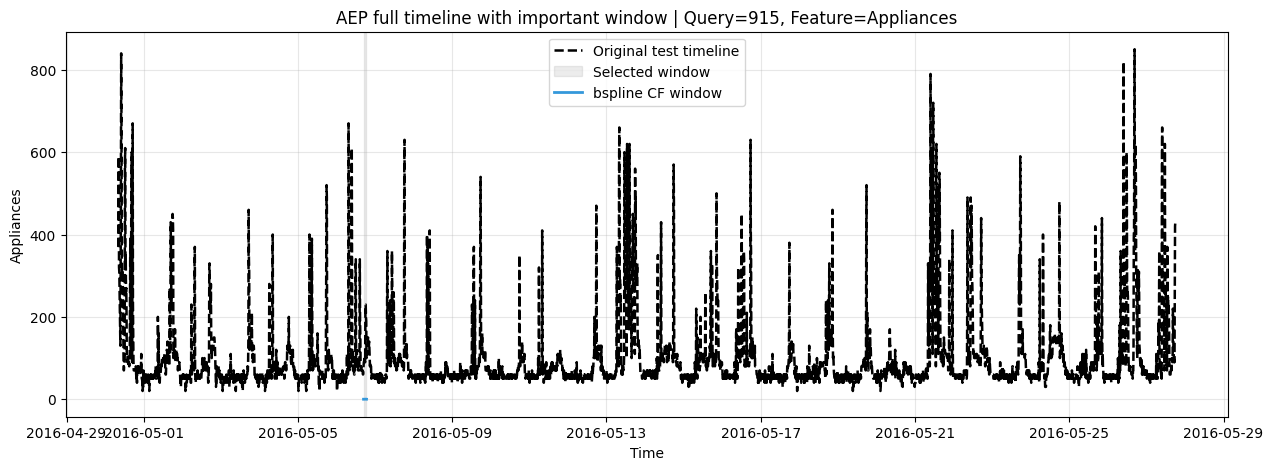

In [45]:
# %%
best_query_idx = int(important_windows_df.iloc[0]["query_idx"])
best_feature = top_sensors_df["feature_name"].iloc[0]

plot_aep_full_timeline_with_window(
    aep_timeline_df=aep_timeline_df,
    aep_meta_df=aep_meta_df,
    x_vs_xcf_df=x_vs_xcf_df,
    query_idx=best_query_idx,
    feature_name=best_feature,
    method="bspline",
    cf_id=0,
    save_path=VIZ_DIR / f"aep_timeline_query{best_query_idx}_{best_feature}.png",
)

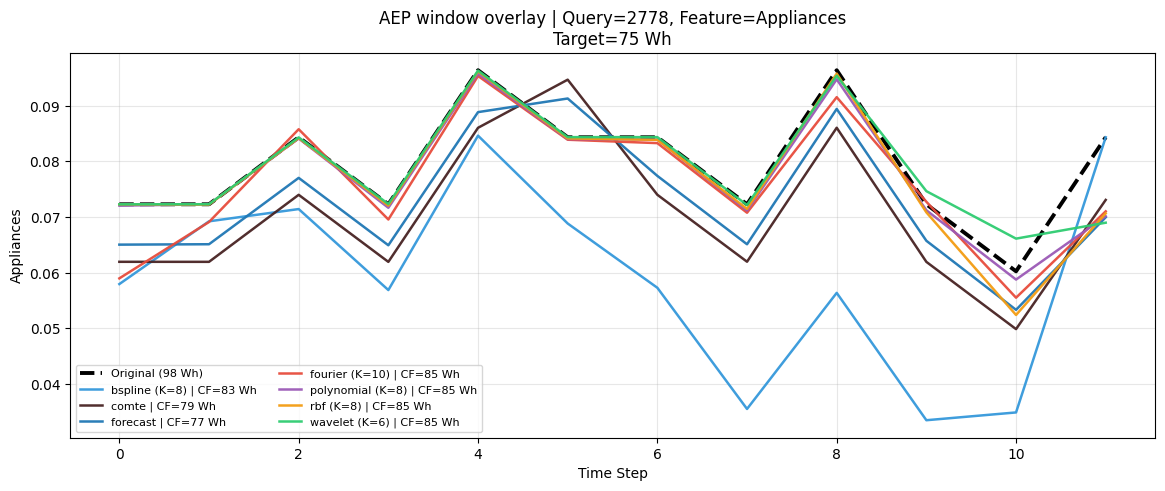

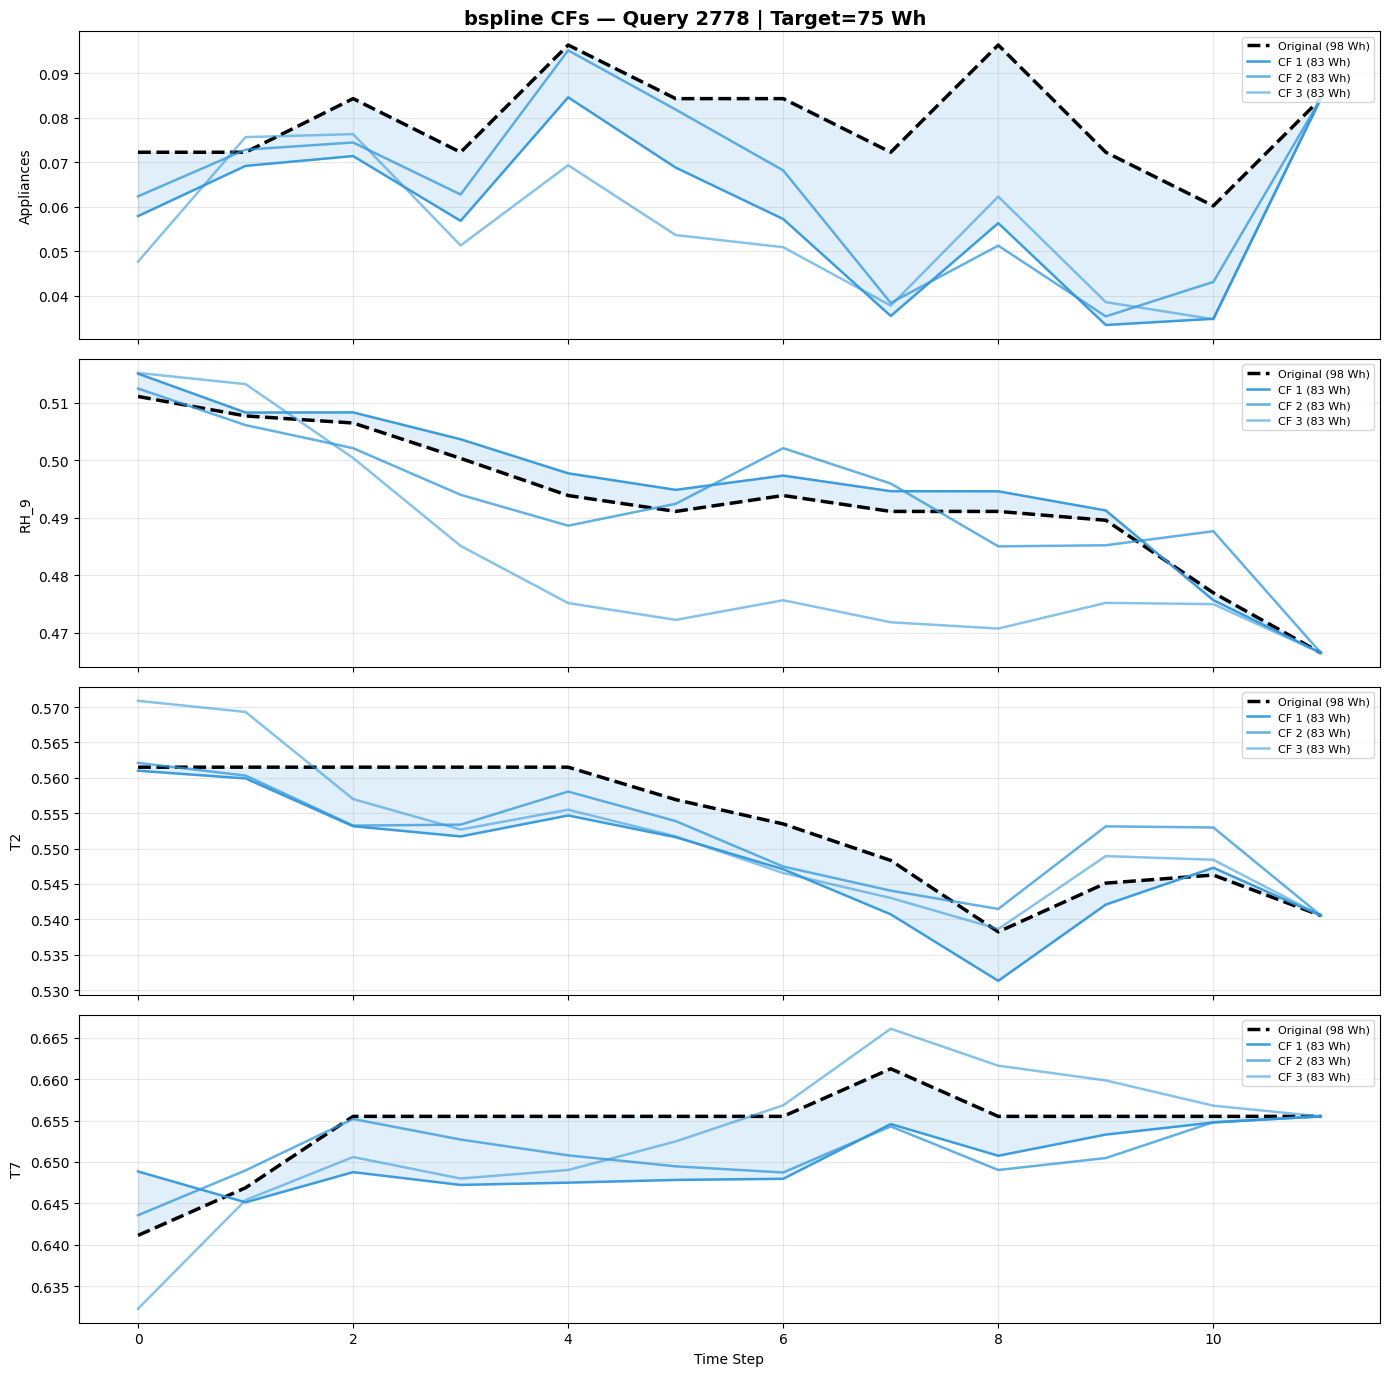

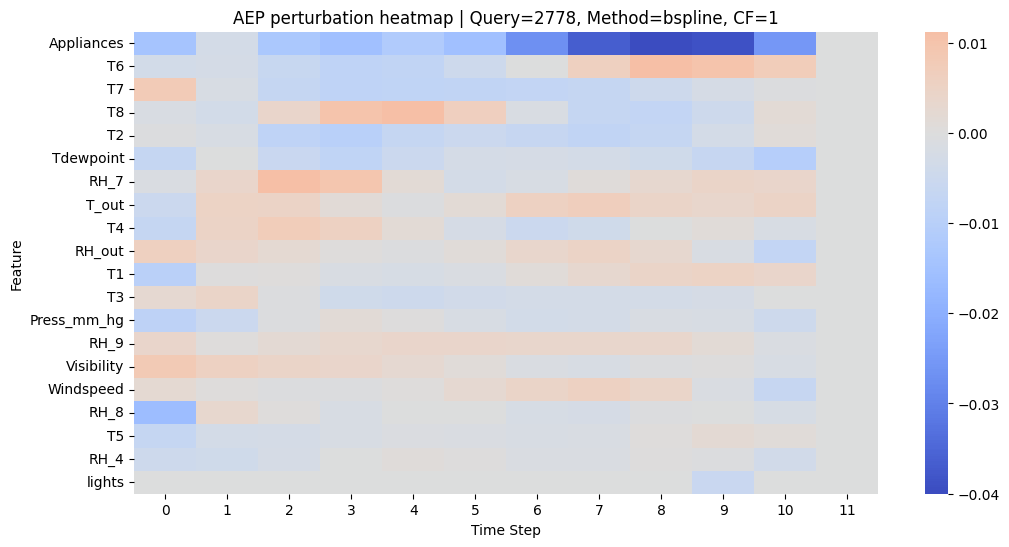

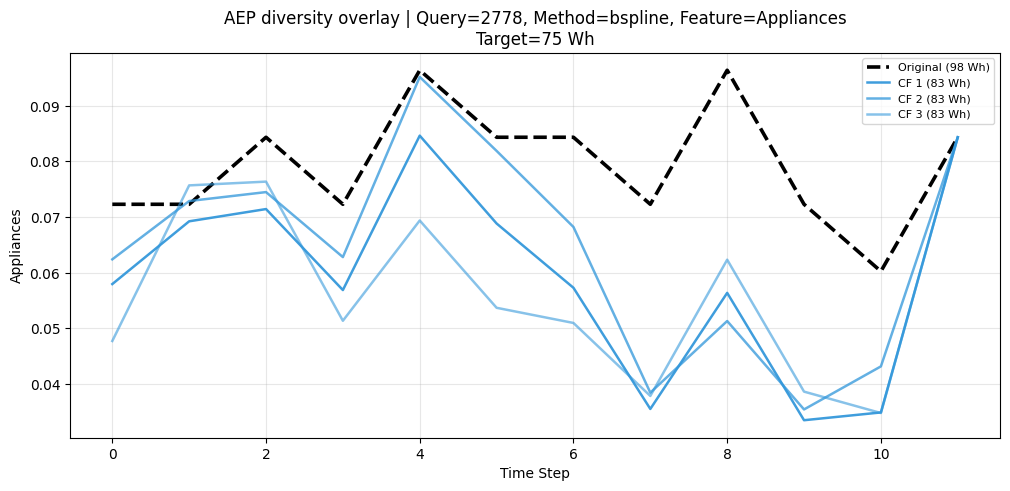

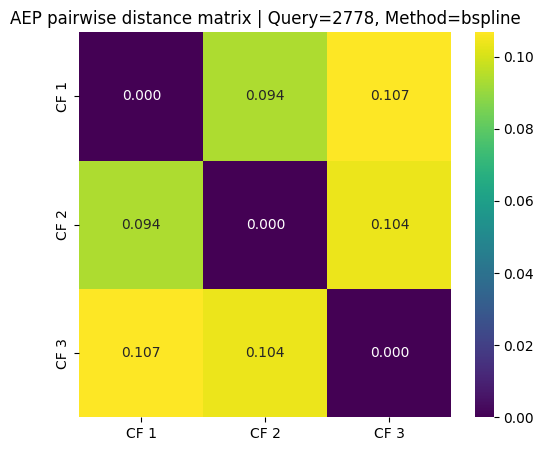

Mean pairwise diversity: 0.10138609481274197


In [61]:
# %%
example_query = int(query_indices[3])

top_feat = top_changed_features_df(
    x_vs_xcf_df=x_vs_xcf_df,
    query_idx=example_query,
    method="bspline",
    top_n=1,
    exclude_feature_idxs=context_idxs,
)["feature_name"].iloc[0]

plot_window_all_methods_overlay(
    x_vs_xcf_df=x_vs_xcf_df,
    query_idx=example_query,
    feature_name=top_feat,
    cf_id=0,
    save_path=VIZ_DIR / f"aep_query{example_query}_all_methods_overlay.png",
)

plot_window_method_top_features(
    x_vs_xcf_df=x_vs_xcf_df,
    query_idx=example_query,
    method="bspline",
    top_n=4,
    save_path=VIZ_DIR / f"aep_query{example_query}_bspline_top4.png",
)

plot_window_perturbation_heatmap(
    x_vs_xcf_df=x_vs_xcf_df,
    query_idx=example_query,
    method="bspline",
    cf_id=0,
    save_path=VIZ_DIR / f"aep_query{example_query}_bspline_heatmap.png",
)

plot_window_diversity_overlay(
    x_vs_xcf_df=x_vs_xcf_df,
    query_idx=example_query,
    method="bspline",
    feature_name=top_feat,
    save_path=VIZ_DIR / f"aep_query{example_query}_bspline_diversity_overlay.png",
)

D, div_score = plot_window_diversity_distance_matrix(
    x_vs_xcf_df=x_vs_xcf_df,
    query_idx=example_query,
    method="bspline",
    use="delta",
    save_path=VIZ_DIR / f"aep_query{example_query}_bspline_diversity_matrix.png",
)

print("Mean pairwise diversity:", div_score)

In [1]:
# %% Reload eval_df and rebuild summary table
from pathlib import Path
import numpy as np
import pandas as pd

eval_path = Path("/workspace/nirban/vaibhav/counterfactual_basis_kernel/notebooks/AEP/cf_experiment_outputs/AEP/eval_df_aep.pkl")
eval_df = pd.read_pickle(eval_path)

print("Loaded:", eval_path)
print("Shape :", eval_df.shape)
print("Cols  :", eval_df.columns.tolist())

# Ensure positive diversity column for reporting
if "diversity_pos" not in eval_df.columns:
    if "diversity_pairwise" in eval_df.columns:
        eval_df["diversity_pos"] = eval_df["diversity_pairwise"].astype(float).clip(lower=0.0)
    else:
        # log-style diversity -> positive space
        eval_df["diversity_pos"] = np.exp(eval_df["diversity"].astype(float))

preferred_order = ["bspline", "rbf", "wavelet", "polynomial", "fourier", "comte", "forecast"]
methods = [m for m in preferred_order if m in eval_df["method"].unique()]

summary = (
    eval_df[eval_df["method"].isin(methods)]
    .groupby("method", as_index=False)
    .agg(
        n=("method", "size"),
        hit_rate=("is_valid", "mean"),
        validity=("validity", "mean"),
        proximity=("proximity", "mean"),
        coeff_sparse=("coeff_sparsity", "mean"),
        group_sparse=("group_sparsity", "mean"),
        smoothness=("smoothness", "mean"),
        diversity_pos=("diversity_pos", "mean"),
        total=("total", "mean"),
    )
)

summary["method"] = pd.Categorical(summary["method"], categories=methods, ordered=True)
summary = summary.sort_values("method").reset_index(drop=True)

print("\n" + "=" * 120)
print("AVERAGE RESULTS (RELOADED FROM PKL)")
print("=" * 120)
print(summary.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

Loaded: /workspace/nirban/vaibhav/counterfactual_basis_kernel/notebooks/AEP/cf_experiment_outputs/AEP/eval_df_aep.pkl
Shape : (140, 23)
Cols  : ['query_idx', 'method', 'K', 'pred_wh_orig', 'pred_wh_cf', 'target_wh', 'target_norm', 'band_lo_norm', 'band_hi_norm', 'band_lo_wh', 'band_hi_wh', 'validity', 'proximity', 'coeff_sparsity', 'group_sparsity', 'smoothness', 'diversity', 'diversity_pairwise', 'total', 'is_valid', 'pred_summary', 'point_gap_norm', 'band_hit']

AVERAGE RESULTS (RELOADED FROM PKL)
    method  n  hit_rate  validity  proximity  coeff_sparse  group_sparse  smoothness  diversity_pos    total
   bspline 20  0.850000  0.000059   0.000101           NaN      0.370911    0.000117       0.040497 0.371189
       rbf 20  1.000000  0.000000   0.000007           NaN      0.069974    0.000001       0.005984 0.069982
   wavelet 20  0.950000  0.000014   0.000039           NaN      0.130120    0.000237       0.006924 0.130411
polynomial 20  1.000000  0.000000   0.000005           NaN 